In [10]:
%load_ext autoreload
%autoreload 2

# Python Kernel on mac: /opt/anaconda3/bin/python

from datetime import date
from pathlib import Path

import era5_temperature as era

from era5_temperature import (
    Location,
    download_era5,
    compute_daily_statistics,
    compute_daily_climatology,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
location = era.Location(
    name="Bruxelles",
    latitude=50.85,
    longitude=4.35,
)

era.download_era5(
    location=location,
    start_date=date(2026, 8, 1),
    end_date=date(2026, 8, 10),
    target=Path("test.zip"),
)

09:52:02 | INFO | Downloading ERA5 for Bruxelles: 2026-08-01 -> 2026-08-10


2026-08-20 09:52:03,145 INFO Request ID is 23fbbc88-67b3-4520-a41c-6f95224f1eac
09:52:03 | INFO | Request ID is 23fbbc88-67b3-4520-a41c-6f95224f1eac
2026-08-20 09:52:03,227 INFO status has been updated to accepted
09:52:03 | INFO | status has been updated to accepted
2026-08-20 09:52:37,347 INFO status has been updated to running
09:52:37 | INFO | status has been updated to running
2026-08-20 09:52:54,520 INFO status has been updated to successful
09:52:54 | INFO | status has been updated to successful
09:52:54 | INFO | Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-08-19/d7a8590242f171c4d9057b18bbc20346.zip


d7a8590242f171c4d9057b18bbc20346.zip:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

10:10:29 | INFO | Reading ERA5 CSV: reanalysis-era5-single-levels-timeseries-sfc017jcj33.csv


<Axes: xlabel='time'>

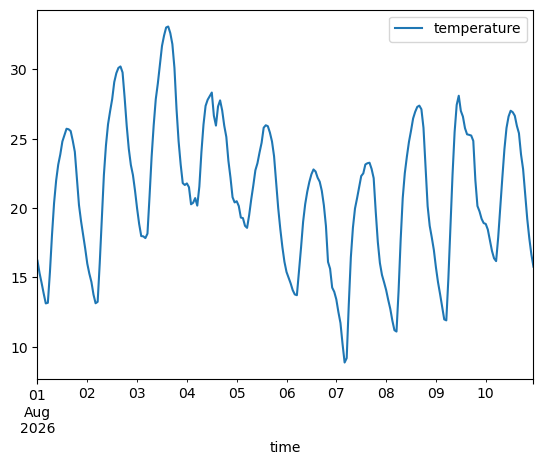

In [5]:
hourly = era.read_era5_csv_zip(
    Path("test.zip")
)

hourly.head()
hourly.plot()

10:12:13 | INFO | Computing daily statistics.


<Axes: xlabel='time'>

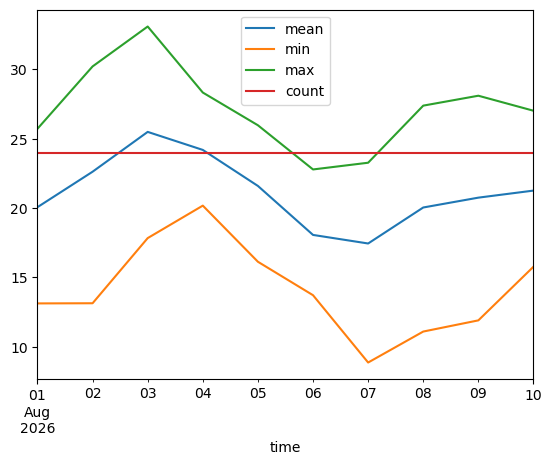

In [12]:
daily = compute_daily_statistics(hourly)
daily.plot()